Dataset Loaded: (200000, 46)
Original Dataset Shape: (200000, 46)
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_

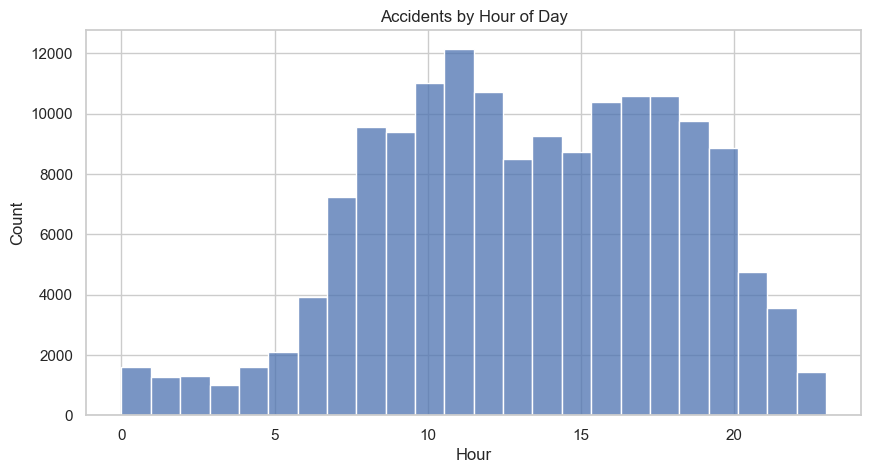

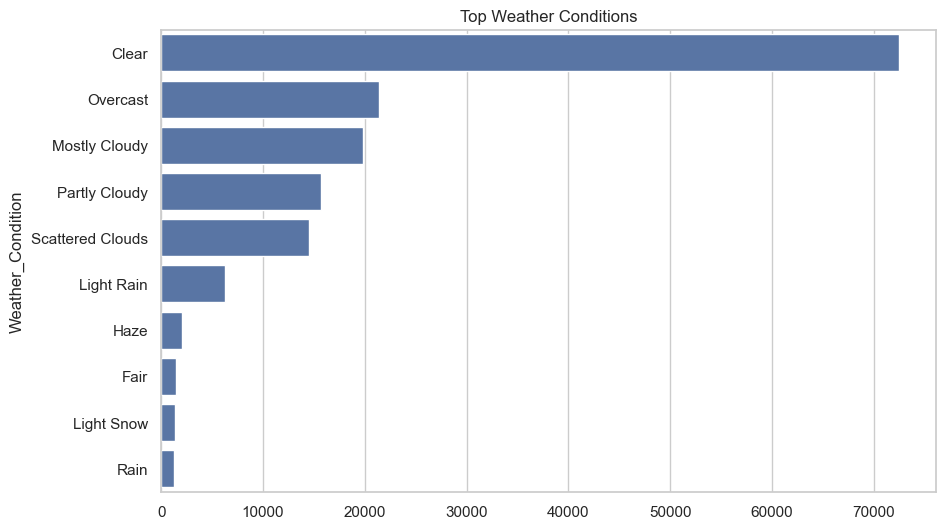

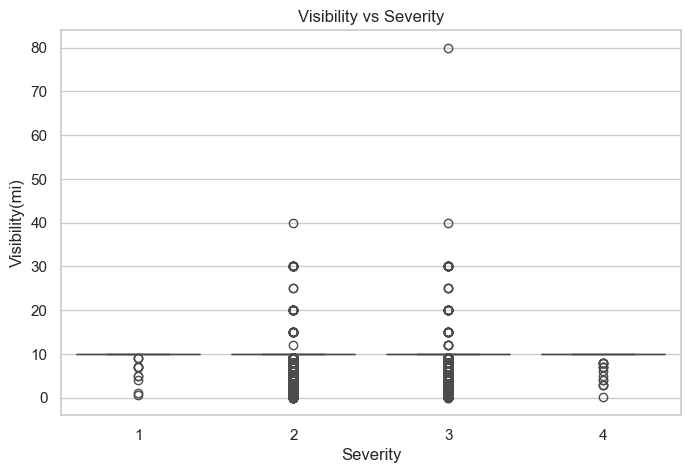

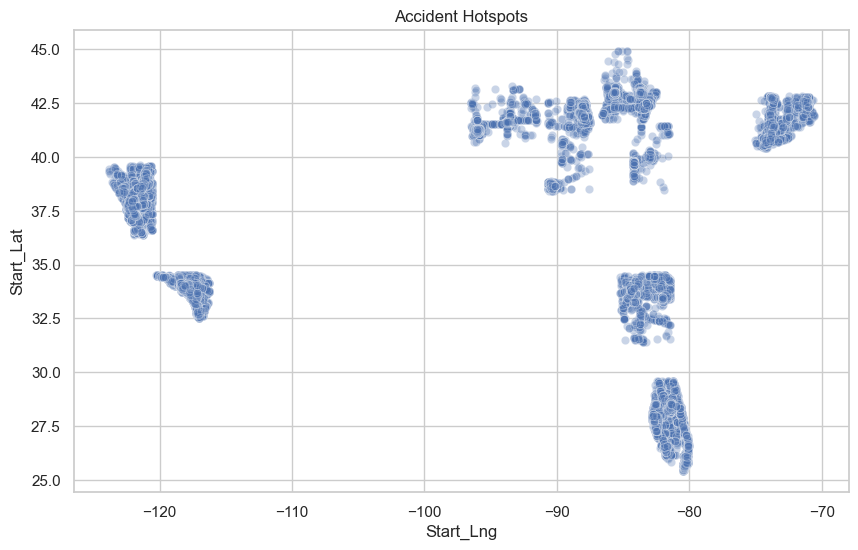

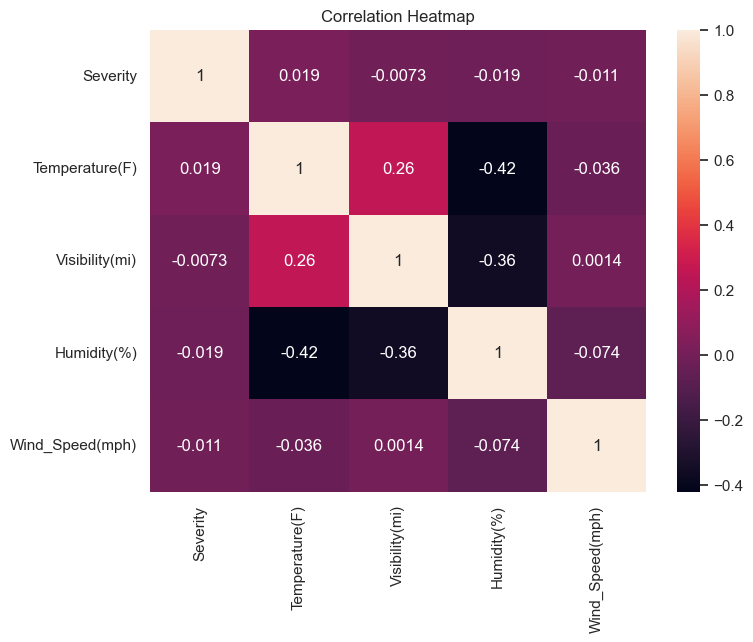

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

sns.set(style="whitegrid")

path = kagglehub.dataset_download(
    "sobhanmoosavi/us-accidents"
)

file_path = os.path.join(
    path,
    "US_Accidents_March23.csv"
)

df = pd.read_csv(
    file_path,
    nrows=200000   # prevents crashing
)

print("Dataset Loaded:", df.shape)
print("Original Dataset Shape:", df.shape)

print(df.head())

df = df[[
    'Severity',
    'Start_Time',
    'Weather_Condition',
    'Temperature(F)',
    'Visibility(mi)',
    'Humidity(%)',
    'Wind_Speed(mph)',
    'Start_Lat',
    'Start_Lng'
]]

df = df.dropna()

print("Cleaned Shape:", df.shape)

df['Start_Time'] = pd.to_datetime(
    df['Start_Time'],
    format='mixed',
    errors='coerce'
)

df['Hour'] = df['Start_Time'].dt.hour

# TIME OF DAY ANALYSIS

plt.figure(figsize=(10,5))

sns.histplot(
    df['Hour'],
    bins=24
)

plt.title("Accidents by Hour of Day")
plt.show()

# WEATHER ANALYSIS

top_weather = df[
    'Weather_Condition'
].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_weather.values,
    y=top_weather.index
)

plt.title("Top Weather Conditions")
plt.show()


# VISIBILITY VS SEVERITY

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Severity',
    y='Visibility(mi)',
    data=df
)

plt.title("Visibility vs Severity")
plt.show()


# ACCIDENT HOTSPOTS

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Start_Lng'],
    y=df['Start_Lat'],
    alpha=0.3
)

plt.title("Accident Hotspots")
plt.show()


# CORRELATION HEATMAP

numeric_cols = df[[
    'Severity',
    'Temperature(F)',
    'Visibility(mi)',
    'Humidity(%)',
    'Wind_Speed(mph)'
]]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()